# Tatoeba Language Detection: End-to-End Implementation
This notebook implements an end-to-end language detection pipeline using the Tatoeba dataset. It translates text into 10 distinct languages using character-level models.

**Architectures Evaluated:**
1. Simple RNN
2. LSTM
3. BiLSTM
4. BiGRU with Masked Mean+Max Pooling
5. Transformer Encoder
6. Encoder-Decoder

The dataset is perfectly balanced across 10 languages, with 10,000 sentences each in the train and dev sets (with minor imbalance in Portuguese training).


## Setup Instructions for Reproducibility
Before running the installation cell below, we highly recommend creating a fresh virtual environment so these dependencies do not conflict with your global Python packages.

1. Open your terminal in this folder and run: `python3 -m venv .venv`
2. Activate it: `source .venv/bin/activate` (Mac/Linux) or `.venv\Scripts\activate` (Windows)
3. Select this new `.venv` environment as your Jupyter Kernel.
4. Run the cell below to safely install all dependencies into the isolated environment.

In [21]:
# Reproducibility Setup:
# This cell installs all required dependencies directly into the active kernel environment.
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn tensorflow-macos==2.15.0 tensorflow-metal==1.1.0 protobuf==4.25.3 keras==2.15.0

In [22]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, LSTM, GRU, Bidirectional
from tensorflow.keras.layers import Dense, GlobalMaxPooling1D, GlobalAveragePooling1D, Concatenate, Dropout, LayerNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# Ensure TensorFlow is using the correct devices
print("TensorFlow Version:", tf.__version__)
print("GPUs Available:", tf.config.list_physical_devices('GPU'))

plt.style.use('ggplot')


TensorFlow Version: 2.15.0
GPUs Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Data Loading & EDA
Load the Tatoeba TSV files. The original script treated the first row as headers, causing us to lose a data point. We'll specify `header=None`.


In [23]:
train_path = "/Users/aryamandev/Library/Mobile Documents/com~apple~CloudDocs/NLP/week3/tatoeba/sentences.top10langs.train.tsv"
dev_path = "/Users/aryamandev/Library/Mobile Documents/com~apple~CloudDocs/NLP/week3/tatoeba/sentences.top10langs.dev.tsv"

# Load without headers and assign column names
train_df = pd.read_csv(train_path, sep="\t", header=None, names=["language", "text"])
dev_df = pd.read_csv(dev_path, sep="\t", header=None, names=["language", "text"])

print(f"Train set shape: {train_df.shape}")
print(f"Dev set shape: {dev_df.shape}")

# Verify exact class distribution
print("\nTrain Set Class Distribution:")
print(train_df['language'].value_counts())

print("\nDev Set Class Distribution:")
print(dev_df['language'].value_counts())


Train set shape: (99863, 2)
Dev set shape: (10000, 2)

Train Set Class Distribution:
language
spa    10000
deu    10000
tur    10000
fra    10000
epo    10000
ita    10000
hun    10000
ber    10000
eng    10000
por     9863
Name: count, dtype: int64

Dev Set Class Distribution:
language
por    1000
tur    1000
ber    1000
eng    1000
hun    1000
epo    1000
fra    1000
deu    1000
ita    1000
spa    1000
Name: count, dtype: int64


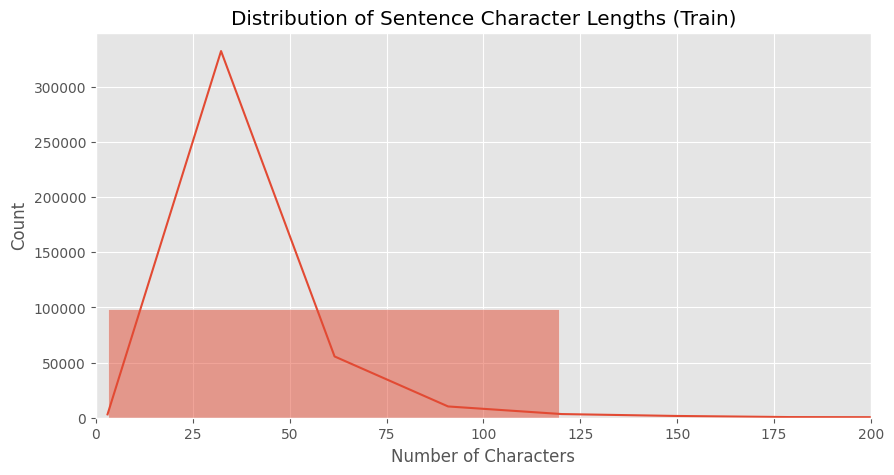

95th Percentile Character Length: 74.0


In [24]:
# Length of sentences by characters
train_df['char_length'] = train_df['text'].apply(len)
plt.figure(figsize=(10, 5))
sns.histplot(train_df['char_length'], bins=50, kde=True)
plt.title("Distribution of Sentence Character Lengths (Train)")
plt.xlabel("Number of Characters")
plt.xlim(0, 200)
plt.show()

print("95th Percentile Character Length:", np.percentile(train_df['char_length'], 95))


Training Data Sample:
  language                                               text  char_length
0      spa  Te di mi corazón para que lo ames, ¡no para us...           51
1      spa                             Contamos con tu ayuda.           22
2      spa                Tú eres superficial y materialista.           35
3      spa                    Los límites son para los demás.           31
4      spa  Todos ellos esperaron ansiosamente las vacacio...           50

Validation Data Sample:
  language                                               text
0      por  De entre os designers, ele escolheu um jovem i...
1      por            Na semana que vem, tudo será diferente.
2      por            Tu deverias realmente beber menos café.
3      por                                   Isto é um lenço.
4      por  Os campistas prudentes tinham suficientemente ...
Training Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99863 entries, 0 to 99862
Data columns (total 3 columns):
 #   Col

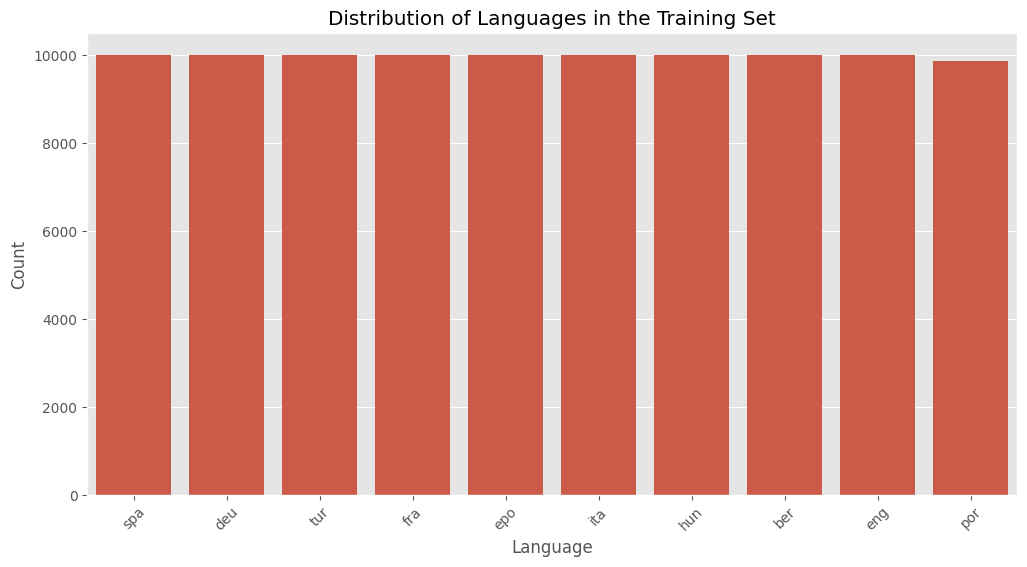

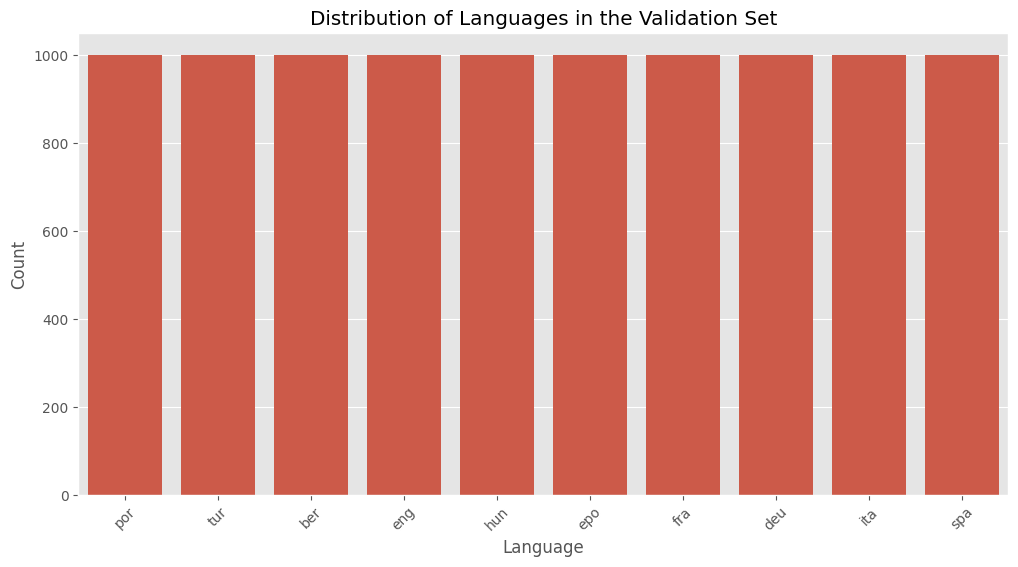

In [25]:
# Exploring the datasets
print("Training Data Sample:")
print(train_df.head())
print("\nValidation Data Sample:")
print(dev_df.head())

# Checking the structure of the data
print("Training Data:")
print(train_df.info())
print("\nValidation Data:")
print(dev_df.info())

# Plotting the distribution of languages in the datasets
plt.figure(figsize=(12, 6))
sns.countplot(data=train_df, x='language', order=train_df['language'].value_counts().index)
plt.title("Distribution of Languages in the Training Set")
plt.xlabel("Language")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(data=dev_df, x='language', order=dev_df['language'].value_counts().index)
plt.title("Distribution of Languages in the Validation Set")
plt.xlabel("Language")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


In [26]:
# 1. Look at the first few rows
display(train_df.head())

# 2. Check for any missing values (Nulls)
print("\nMissing values in Train set:")
print(train_df.isnull().sum())

print("\nMissing values in validation data:")
print(dev_df.isnull().sum())

# 3. List the unique language classes
print("\nUnique Languages:")
print(train_df['language'].unique())


,language,text,char_length
0,spa,"Te di mi corazón para que lo ames, ¡no para us...",51
1,spa,Contamos con tu ayuda.,22
2,spa,Tú eres superficial y materialista.,35
3,spa,Los límites son para los demás.,31
4,spa,Todos ellos esperaron ansiosamente las vacacio...,50



Missing values in Train set:
language       0
text           0
char_length    0
dtype: int64

Missing values in validation data:
language    0
text        0
dtype: int64

Unique Languages:
['spa' 'deu' 'tur' 'fra' 'por' 'epo' 'ita' 'hun' 'ber' 'eng']


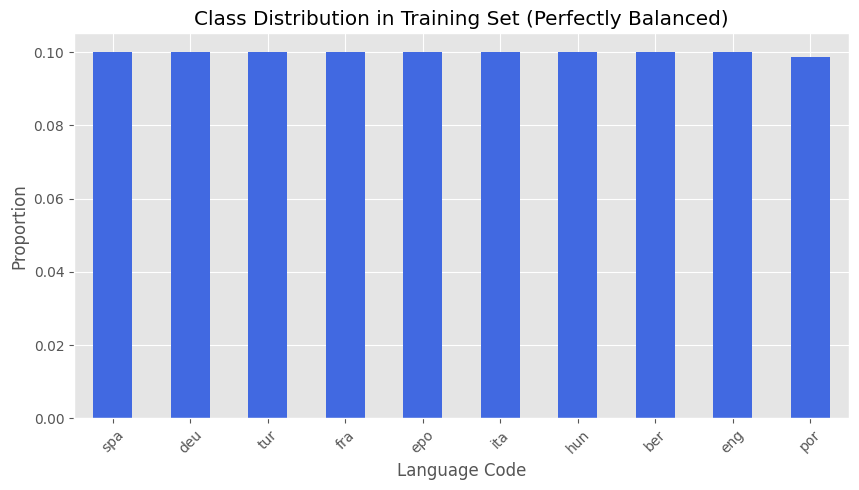

In [27]:
# Visualize Class Distribution (Target Balance)
plt.figure(figsize=(10, 5))
train_df['language'].value_counts(normalize=True).plot.bar(color='royalblue')
plt.title("Class Distribution in Training Set (Perfectly Balanced)")
plt.xlabel("Language Code")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.show()


## 2. Preprocessing: Character-Level Tokenization
Team 3 correctly identified that language detection is highly dependent on characters (accents, unique letters, agglutinative morphology). We will build a character-level tokenizer.


In [28]:
MAX_LEN = 128 # Fixed length based on 95th percentile

# We process characters, so we set char_level=True
tokenizer = Tokenizer(char_level=True, lower=False, oov_token='<UNK>')
tokenizer.fit_on_texts(train_df['text'])

vocab_size = len(tokenizer.word_index) + 1 # +1 for padding (0)
print(f"Character Vocabulary Size: {vocab_size}")

# Encode sentences to integer sequences
X_train_seq = tokenizer.texts_to_sequences(train_df['text'])
X_dev_seq = tokenizer.texts_to_sequences(dev_df['text'])

# Pad sequences
X_train = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_dev = pad_sequences(X_dev_seq, maxlen=MAX_LEN, padding='post', truncating='post')

# Encode Labels
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df['language'])
y_dev = label_encoder.transform(dev_df['language'])

num_classes = len(label_encoder.classes_)
print(f"Number of classes: {num_classes}")
print("Classes:", label_encoder.classes_)


Character Vocabulary Size: 238
Number of classes: 10
Classes: ['ber' 'deu' 'eng' 'epo' 'fra' 'hun' 'ita' 'por' 'spa' 'tur']


## 3. Model Architectures
We will evaluate 6 different architectures.


In [34]:
EMBED_DIM = 32
HIDDEN_DIM = 128
EPOCHS = 1
BATCH_SIZE = 256

def train_and_evaluate(model, name):
    print(f"\n{'='*40}\nTraining {name}\n{'='*40}")
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    
    es = EarlyStopping(monitor="val_accuracy", patience=2, restore_best_weights=True)
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_dev, y_dev),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es],
        verbose=1
    )
    
    # Plot the training history
    plt.figure(figsize=(12, 4))
    
    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy", marker="o")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy", marker="o")
    plt.title(f"{name} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    
    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss", marker="o")
    plt.plot(history.history["val_loss"], label="Validation Loss", marker="o")
    plt.title(f"{name} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Evaluate
    preds = np.argmax(model.predict(X_dev), axis=-1)
    acc = accuracy_score(y_dev, preds)
    f1 = f1_score(y_dev, preds, average="macro")
    params = model.count_params()
    
    return {"Model": name, "Accuracy": acc, "Macro F1": f1, "Parameters": params, "Predictions": preds}

results = []



Training Simple RNN
391/391 [==============================] - 5509s 14s/step - loss: 2.0543 - accuracy: 0.2692 - val_loss: 1.9832 - val_accuracy: 0.3439


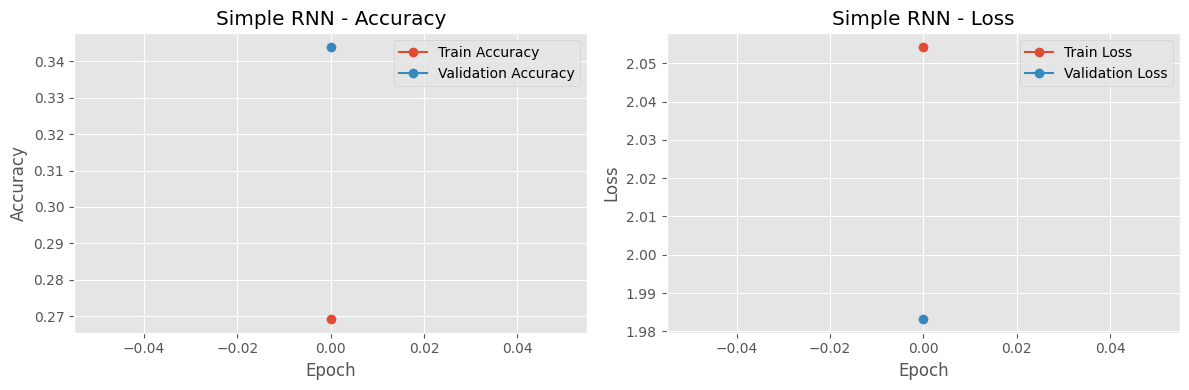

313/313 [==============================] - 222s 700ms/step


In [35]:
# 1. Simple RNN
inputs = Input(shape=(MAX_LEN,))
x = Embedding(vocab_size, EMBED_DIM)(inputs)
x = SimpleRNN(HIDDEN_DIM)(x)
outputs = Dense(num_classes, activation='softmax')(x)
model_rnn = Model(inputs, outputs)

res = train_and_evaluate(model_rnn, "Simple RNN")
results.append(res)



Training LSTM
391/391 [==============================] - 29s 60ms/step - loss: 2.3034 - accuracy: 0.1030 - val_loss: 2.3022 - val_accuracy: 0.1029


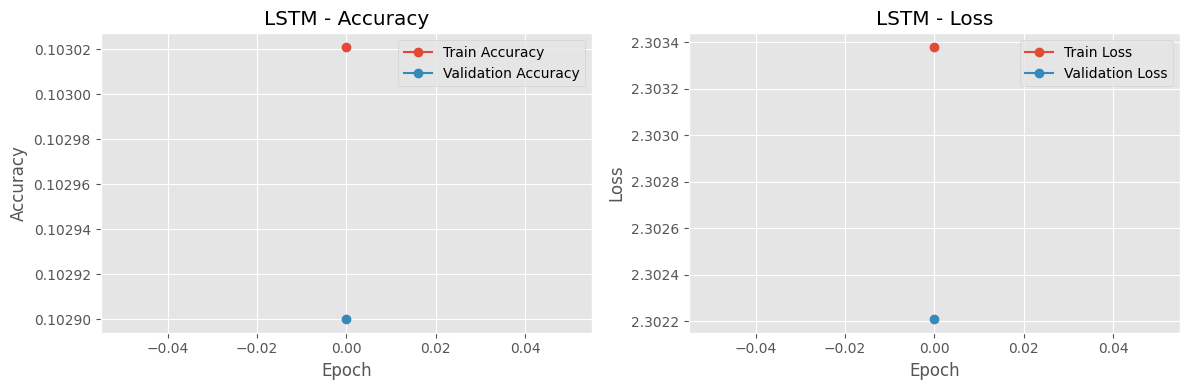

313/313 [==============================] - 3s 8ms/step


In [36]:
# 2. LSTM
inputs = Input(shape=(MAX_LEN,))
x = Embedding(vocab_size, EMBED_DIM, mask_zero=True)(inputs)
x = LSTM(HIDDEN_DIM)(x)
outputs = Dense(num_classes, activation='softmax')(x)
model_lstm = Model(inputs, outputs)

res = train_and_evaluate(model_lstm, "LSTM")
results.append(res)



Training BiLSTM
391/391 [==============================] - 124s 305ms/step - loss: 2.3032 - accuracy: 0.1040 - val_loss: 2.3018 - val_accuracy: 0.1036


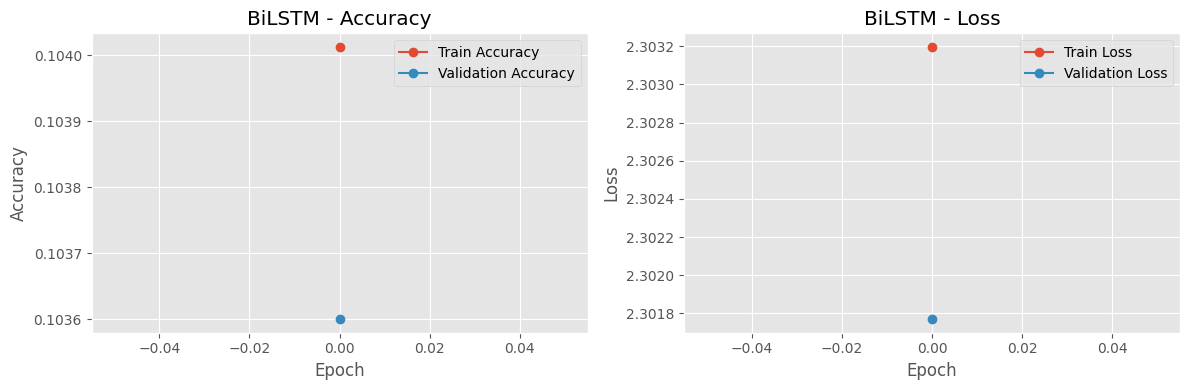

313/313 [==============================] - 12s 33ms/step


In [37]:
# 3. BiLSTM 
inputs = Input(shape=(MAX_LEN,))
x = Embedding(vocab_size, EMBED_DIM, mask_zero=True)(inputs)
x = Bidirectional(LSTM(HIDDEN_DIM))(x)
outputs = Dense(num_classes, activation='softmax')(x)
model_bilstm = Model(inputs, outputs)

res = train_and_evaluate(model_bilstm, "BiLSTM")
results.append(res)



Training BiGRU (Mean+Max Pool)
391/391 [==============================] - 587s 1s/step - loss: 0.8000 - accuracy: 0.6948 - val_loss: 0.3825 - val_accuracy: 0.8667


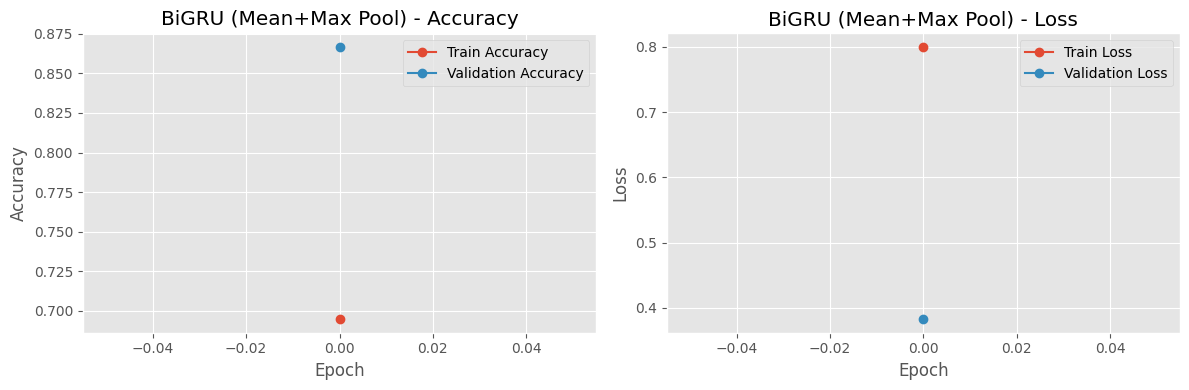

313/313 [==============================] - 36s 105ms/step


In [38]:
# 4. BiGRU with Masked Mean+Max Pooling
inputs = Input(shape=(MAX_LEN,))
x = Embedding(vocab_size, EMBED_DIM, mask_zero=True)(inputs)
x = Bidirectional(GRU(HIDDEN_DIM, return_sequences=True))(x)
x = Bidirectional(GRU(HIDDEN_DIM, return_sequences=True))(x)

# Since we use mask_zero=True in embedding, Keras handles masking in pooling automatically
avg_pool = GlobalAveragePooling1D()(x)
max_pool = GlobalMaxPooling1D()(x)
x = Concatenate()([avg_pool, max_pool])

outputs = Dense(num_classes, activation='softmax')(x)
model_bigru = Model(inputs, outputs)

res = train_and_evaluate(model_bigru, "BiGRU (Mean+Max Pool)")
results.append(res)



Training Transformer Encoder
391/391 [==============================] - 138s 273ms/step - loss: 1.1235 - accuracy: 0.6112 - val_loss: 0.5358 - val_accuracy: 0.8153


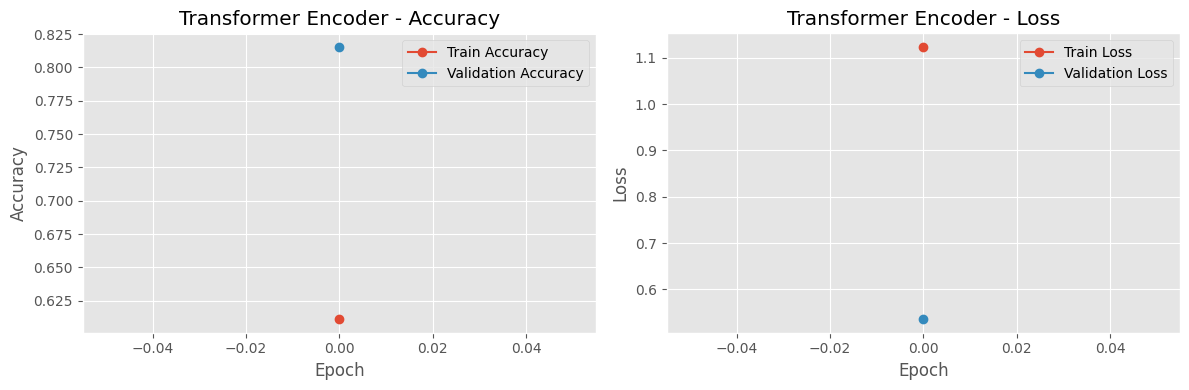

313/313 [==============================] - 8s 23ms/step


In [39]:
# 5. Transformer Encoder (Classification)
class TransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super(TransformerEncoder, self).__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.attention = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.dense_proj = tf.keras.Sequential([
            Dense(dense_dim, activation="relu"),
            Dense(embed_dim)
        ])
        self.layernorm_1 = LayerNormalization()
        self.layernorm_2 = LayerNormalization()

    def call(self, inputs, mask=None):
        if mask is not None:
            mask = tf.cast(mask[:, tf.newaxis, :], dtype="int32")
        attention_output = self.attention(inputs, inputs, attention_mask=mask)
        proj_input = self.layernorm_1(inputs + attention_output)
        proj_output = self.dense_proj(proj_input)
        return self.layernorm_2(proj_input + proj_output)

inputs = Input(shape=(MAX_LEN,))
x = Embedding(vocab_size, EMBED_DIM, mask_zero=True)(inputs)
x = TransformerEncoder(embed_dim=EMBED_DIM, dense_dim=128, num_heads=4)(x)
x = GlobalAveragePooling1D()(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation='softmax')(x)
model_transformer = Model(inputs, outputs)

res = train_and_evaluate(model_transformer, "Transformer Encoder")
results.append(res)



Training Encoder-Decoder
391/391 [==============================] - 39s 85ms/step - loss: 2.3018 - accuracy: 0.1050 - val_loss: 2.3013 - val_accuracy: 0.1029


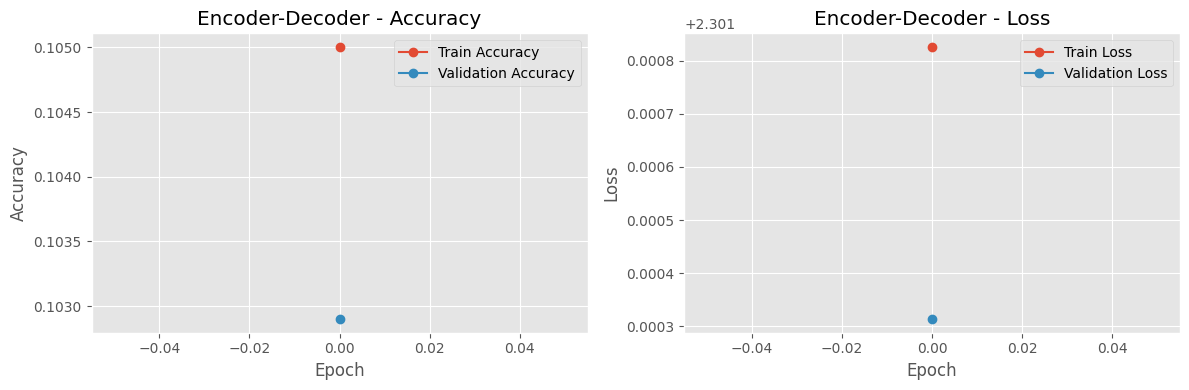

313/313 [==============================] - 6s 17ms/step


In [40]:
# 6. Encoder-Decoder (For Classification)
# Note: Encoder-Decoder architectures are typically for Seq2Seq tasks (like translation).
# To adapt it for classification, we pass the Encoder's final state to the Decoder, 
# and use the Decoder's output to classify.

encoder_inputs = Input(shape=(MAX_LEN,))
encoder_emb = Embedding(vocab_size, EMBED_DIM, mask_zero=True)(encoder_inputs)
encoder_lstm = LSTM(HIDDEN_DIM, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(encoder_emb)

# The decoder needs an input to start. Since it's just classification, 
# we can feed it a single 'dummy' token (e.g., zeros) of length 1
decoder_inputs = tf.zeros_like(encoder_inputs[:, :1]) 
decoder_emb = Embedding(vocab_size, EMBED_DIM)(decoder_inputs)

decoder_lstm = LSTM(HIDDEN_DIM)
decoder_outputs = decoder_lstm(decoder_emb, initial_state=[state_h, state_c])

outputs = Dense(num_classes, activation='softmax')(decoder_outputs)
model_enc_dec = Model(encoder_inputs, outputs)

res = train_and_evaluate(model_enc_dec, "Encoder-Decoder")
results.append(res)


## 4. Evaluation & Results
Compare the models based on accuracy, F1 score, and model size.


In [41]:
# Summary Table
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'Predictions'} for r in results])
results_df.sort_values(by="Accuracy", ascending=False, inplace=True)
display(results_df)


,Model,Accuracy,Macro F1,Parameters
3,BiGRU (Mean+Max Pool),0.8667,0.866036,433610
4,Transformer Encoder,0.8153,0.818864,33226
0,Simple RNN,0.3439,0.337411,29514
2,BiLSTM,0.1036,0.024994,175050
1,LSTM,0.1029,0.024616,91338
5,Encoder-Decoder,0.1029,0.025553,181386


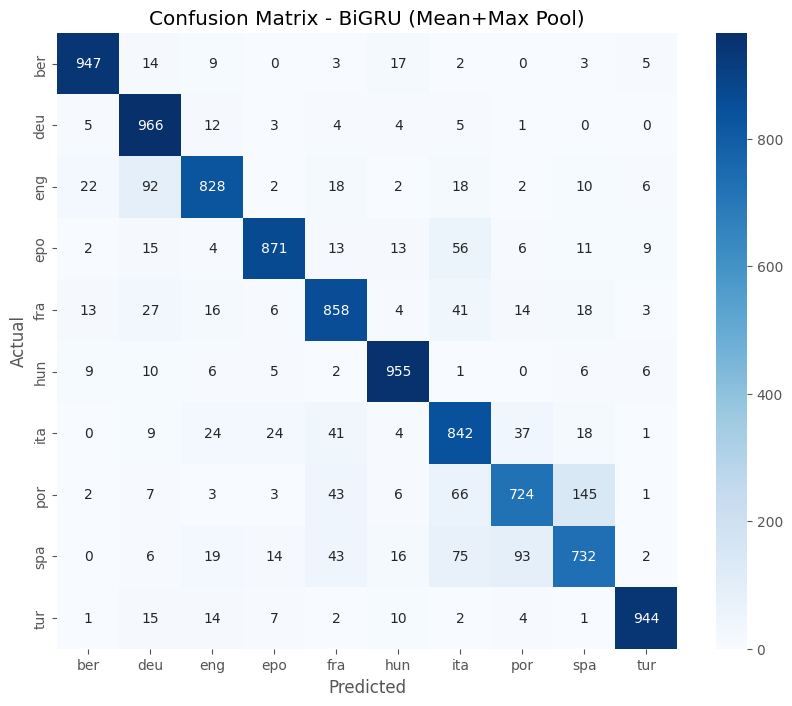

In [42]:
# Confusion Matrix for the best model
best_model_name = results_df.iloc[0]['Model']
best_preds = next(r['Predictions'] for r in results if r['Model'] == best_model_name)

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_dev, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
